In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [2]:
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

print(X.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [3]:
print("\n--- Mean of Dataset ---")
print(X.mean())

print("\n--- Standard Deviation of Dataset ---")
print(X.std())


--- Mean of Dataset ---
MedInc           3.870671
HouseAge        28.639486
AveRooms         5.429000
AveBedrms        1.096675
Population    1425.476744
AveOccup         3.070655
Latitude        35.631861
Longitude     -119.569704
dtype: float64

--- Standard Deviation of Dataset ---
MedInc           1.899822
HouseAge        12.585558
AveRooms         2.474173
AveBedrms        0.473911
Population    1132.462122
AveOccup        10.386050
Latitude         2.135952
Longitude        2.003532
dtype: float64


In [4]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    random_state=42
)

print("\nTraining Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)


Training Set Shape: (14448, 8)
Test Set Shape: (6192, 8)


In [5]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("First 10 Predicted Values:")
print(lr_predictions[:10])

First 10 Predicted Values:
[0.72604907 1.76743383 2.71092161 2.83514727 2.60695807 2.01073856
 2.64067386 2.16706161 2.74012056 3.90361526]


In [6]:

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_predictions)

print("\n--- Linear Regression Performance ---")
print(f"Mean Absolute Error (MAE): {lr_mae:.4f}")
print(f"Mean Squared Error (MSE): {lr_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {lr_rmse:.4f}")
print(f"R2 Score: {lr_r2:.4f}")


--- Linear Regression Performance ---
Mean Absolute Error (MAE): 0.5272
Mean Squared Error (MSE): 0.5306
Root Mean Squared Error (RMSE): 0.7284
R2 Score: 0.5958


In [7]:
performance = pd.DataFrame({
    "Regression Model": ["Linear Regression"],
    "MAE": [lr_mae],
    "MSE": [lr_mse],
    "RMSE": [lr_rmse],
    "R2 Score": [lr_r2]
})

print("\n--- Performance Summary ---")
print(performance.to_string(index=False))


--- Performance Summary ---
 Regression Model      MAE      MSE     RMSE  R2 Score
Linear Regression 0.527247 0.530568 0.728401   0.59577


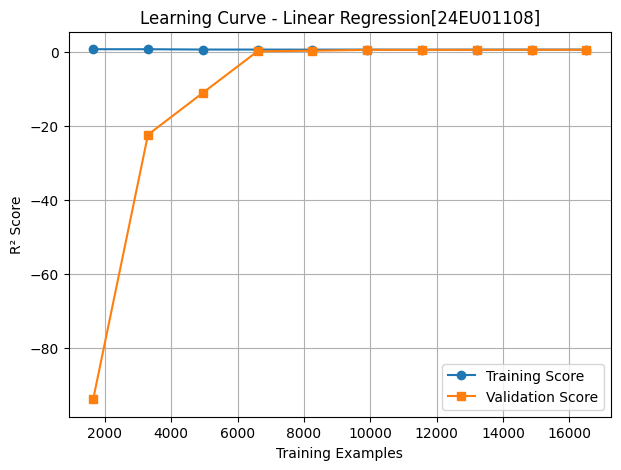

In [8]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(),
    X_scaled,
    y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, test_mean, marker='s', label='Validation Score')

plt.title("Learning Curve - Linear Regression[24EU01108]")
plt.xlabel("Training Examples")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()